
# Module 24: Principal Component Analysis (PCA)

This notebook shows PCA **using a library** (scikit-learn) on a **small dataset**, with detailed explanations for each step.

### What you will learn here
You will learn how to:
1. Understand *why* PCA is useful in practice (beyond theory)
2. Prepare data properly (especially **scaling**, which is not optional most of the time)
3. Fit PCA and interpret **explained variance ratio**
4. Choose the number of components using a clear rule (for example, 90% or 95% variance)
5. Transform the dataset into PCA space
6. Visualize the data in 2D using PC1 and PC2
7. Compare model performance **with and without** PCA (small demo)

### Key idea to keep in mind
PCA does **not** select original features. It creates **new features** (principal components) that are combinations of the original ones.



## 1) Imports and Setup

We will use:
- `sklearn.datasets` for a small dataset
- `StandardScaler` for scaling
- `PCA` for dimensionality reduction
- `matplotlib` for plotting

Why scaling?  
PCA is variance-based. If one feature has a larger numeric scale, it can dominate the variance and hijack PCA. Scaling makes features comparable so PCA captures structure, not unit differences.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


## 2) Load a Small Dataset

We will use the **Wine dataset** (classic, small, and perfect for PCA demos):
- 178 samples
- 13 numeric features
- 3 classes

Why this dataset is good for PCA:
- Features are on different scales (some are small decimals, some are larger)
- Many features are correlated
- PCA often produces a nice 2D visualization


In [2]:
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="class")

X.shape, y.shape

((178, 13), (178,))

In [3]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



## 3) Quick Data Understanding: Feature Scales

Before PCA, always check scales.
If features are on very different ranges, PCA will mainly focus on the largest-scale feature.

Let's look at descriptive stats quickly.


In [4]:
X.describe().T[["mean", "std", "min", "max"]].head(10)

,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00



## 4) Scaling (Standardization)

We standardize features using:

z = (x - mean) / std

This makes each feature have:
- mean approximately 0
- standard deviation approximately 1

This is the most common preprocessing step before PCA.


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.51861254, -0.5622498 ,  0.23205254, -1.16959318,  1.91390522,
         0.80899739,  1.03481896, -0.65956311,  1.22488398,  0.25171685,
         0.36217728,  1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, -2.49084714,  0.01814502,
         0.56864766,  0.73362894, -0.82071924, -0.54472099, -0.29332133,
         0.40605066,  1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, -0.2687382 ,  0.08835836,
         0.80899739,  1.21553297, -0.49840699,  2.13596773,  0.26901965,
         0.31830389,  0.78858745,  1.39514818],
       [ 1.69154964, -0.34681064,  0.4879264 , -0.80925118,  0.93091845,
         2.49144552,  1.46652465, -0.98187536,  1.03215473,  1.18606801,
        -0.42754369,  1.18407144,  2.33457383],
       [ 0.29570023,  0.22769377,  1.84040254,  0.45194578,  1.28198515,
         0.80899739,  0.66335127,  0.22679555,  0.40140444, -0.31927553,
         0.36217728,  0.44960118, -0.03787401]])


## 5) Fit PCA (No Component Limit Yet)

First, we fit PCA with all components. This helps us understand:
- how much variance each component explains
- how quickly variance accumulates

Then we decide how many components to keep (for example, enough to explain 90% or 95% variance).


In [8]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

explained[:13]

array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294,
       0.04935823, 0.04238679, 0.02680749, 0.02222153, 0.01930019,
       0.01736836, 0.01298233, 0.00795215])

In [9]:
cum_explained[:10]

array([0.36198848, 0.55406338, 0.66529969, 0.73598999, 0.80162293,
       0.85098116, 0.89336795, 0.92017544, 0.94239698, 0.96169717])


## 6) Explained Variance Plot (Choosing Components)

This plot answers:
- How many components do we need to retain most information?

Common practical rules:
- Keep enough components to explain 90% variance (aggressive reduction)
- Keep enough components to explain 95% variance (safer)

We will compute both thresholds and also visualize cumulative variance.


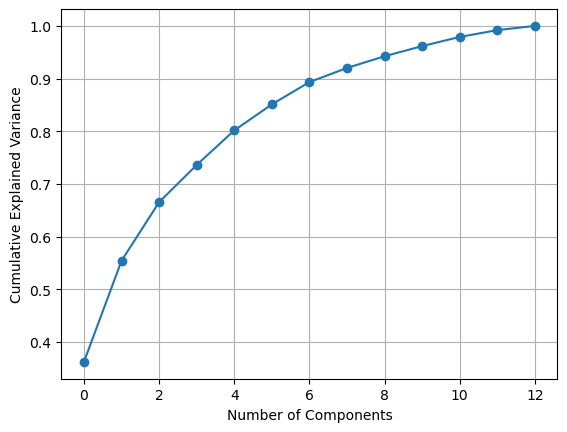

In [10]:
plt.figure()
plt.plot(cum_explained, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

In [11]:
#Selection of k90 and k95
def components_for_threshold(cum_variance,threashold):
  return int(np.argmax(cum_variance>=threashold)+1)

k90 = components_for_threshold(cum_explained, 0.90)
print(k90)

8


In [12]:
k95 = components_for_threshold(cum_explained, 0.95)
print(k95)

10


In [13]:
k97 = components_for_threshold(cum_explained, 0.97)
print(k97)

11


In [14]:
k99 = components_for_threshold(cum_explained, 0.99)
print(k99)

12



Interpretation:
- k90 = minimum number of components to reach at least 90% variance
- k95 = minimum number of components to reach at least 95% variance

We will use k95 for a safer reduction (less information loss).


In [15]:
k = k95
pca = PCA(n_components=k)
X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(178, 10)